In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

In [ ]:
# dataset
url = "water_potability.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
# 1. Check Duplicates
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")
df = df.drop_duplicates()

# 2. Check Missing Values
print("\n--- Missing Values Per Column ---")
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0])

# 3. Check Class Balance (Target: Potability)
print("\n--- Class Balance ---")
print(df['Potability'].value_counts(normalize=True).round(3))

Total Duplicate Rows: 0

--- Missing Values Per Column ---
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

--- Class Balance ---
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


In [ ]:
# Impute missing values with column medians
df = df.fillna(df.median())

# Confirm zero missing values remain
assert df.isnull().sum().sum() == 0, "Missing values still exist!"

# Save cleaned copy in Colab session
df.to_csv('cleaned_water_data.csv', index=False)
print("Data preprocessed and saved as 'cleaned_water_data.csv'.")
print("Total records ready for modeling:", len(df))

Data preprocessed and saved as 'cleaned_water_data.csv'.
Total records ready for modeling: 3276


In [ ]:
# 1. Load Cleaned Dataset
df = pd.read_csv('cleaned_water_data.csv')
X = df.drop(columns=['Potability'])
y = df['Potability']

# 2. Train-Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Define Foundational Candidate Models
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
}

# 4. Train and Compare Models
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    trained_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

# 5. Display Benchmark Table
results_df = pd.DataFrame(results)
print("=== Model Comparison Table ===")
print(results_df.to_string(index=False))

=== Model Comparison Table ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6098     0.0000  0.0000    0.0000   0.5481
      Decision Tree    0.6418     0.5946  0.2578    0.3597   0.6083
      Random Forest    0.6570     0.7719  0.1719    0.2812   0.6752



=== Detailed Classification Report (Random Forest) ===
                 precision    recall  f1-score   support

Not Potable (0)       0.65      0.97      0.77       400
    Potable (1)       0.77      0.17      0.28       256

       accuracy                           0.66       656
      macro avg       0.71      0.57      0.53       656
   weighted avg       0.70      0.66      0.58       656



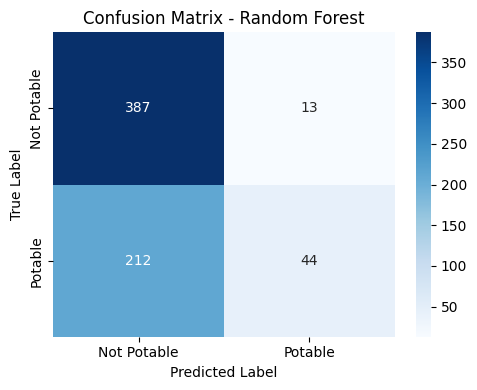

Saved 'water_model.pkl' and 'confusion_matrix.png' to Colab storage!


In [ ]:
# Select the best model (Random Forest)
best_model_name = "Random Forest"
best_model = trained_models[best_model_name]

# Generate predictions & evaluation breakdown
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print(f"\n=== Detailed Classification Report ({best_model_name}) ===")
print(classification_report(y_test, y_pred, target_names=["Not Potable (0)", "Potable (1)"]))

# Plot & Save Confusion Matrix for the Paper/Presentation
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Potable", "Potable"],
            yticklabels=["Not Potable", "Potable"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

# Export Model and Feature Columns for Streamlit
model_payload = {
    "model": best_model,
    "feature_names": list(X.columns)
}

with open("water_model.pkl", "wb") as f:
    pickle.dump(model_payload, f)

print("Saved 'water_model.pkl' and 'confusion_matrix.png' to Colab storage!")